# 📘 Day 29 — Naive Bayes: Theory & Variants

**Author:** Sahil-K-Y 
**Phase:** 3 — Tree Models & SVM 
**Date:** Day 029 of 214-Day AI/ML Roadmap

---
## 📌 Overview

Naive Bayes is one of the **fastest and simplest** classification algorithms. Despite its "naive" independence assumption, it performs **surprisingly well** on text classification, spam detection, and medical diagnosis tasks.

### 🎯 Learning Objectives
- Understand **Bayes' Theorem** and its role in classification
- Learn the **Naive (conditional independence) assumption** and why it works
- Explore all variants: **GaussianNB, MultinomialNB, BernoulliNB, ComplementNB**
- Understand **Laplace Smoothing** and zero-frequency problem
- Apply Naive Bayes on a **real-world text classification** dataset

---
## 🧠 1. Bayes' Theorem — The Foundation

Bayes' Theorem calculates the **posterior probability** of a class given the observed features:

$$P(C_k | X) = \frac{P(X | C_k) \cdot P(C_k)}{P(X)}$$

| Term | Name | Meaning |
|------|------|---------|
| P(Ck given X) | **Posterior** | Probability of class Ck given features X |
| P(X given Ck) | **Likelihood** | Probability of observing X given class Ck |
| P(Ck) | **Prior** | Base probability of class Ck before seeing data |
| P(X) | **Evidence** | Total probability of features (normalization constant) |

### 🔑 Key Insight
We **don't need to compute P(X)** for classification — we just compare posteriors across classes and pick the largest.

---
## 🧠 2. The "Naive" Assumption — Conditional Independence

The **naive** part assumes all features are **conditionally independent** given the class:

$$P(X | C_k) = \prod_{i=1}^{n} P(x_i | C_k)$$

### Why "Naive"?
- In reality, features are **almost never independent** (e.g., word "free" and "win" in spam emails are correlated)
- But this simplification makes computation **extremely fast** and works well in practice

### Why It Still Works?
1. Classification only needs the **correct ranking** of posteriors, not exact probabilities
2. Estimation errors tend to **cancel out** across many features
3. Works exceptionally well in **high-dimensional** spaces (text classification)

---
## 🧠 3. Naive Bayes Variants

### 3.1 GaussianNB
- Assumes features follow a **Gaussian (Normal) distribution**
- Computes **mean** and **variance** for each feature per class
- **Best for:** Continuous numerical features

### 3.2 MultinomialNB
- Assumes features represent **counts or frequencies** (e.g., word counts)
- Uses feature occurrence counts with Multinomial distribution
- **Best for:** Text classification with TF-IDF or Count Vectors

### 3.3 BernoulliNB
- Assumes features are **binary** (0/1, present/absent)
- Explicitly models both presence AND absence of features
- **Best for:** Short text, binary bag-of-words

### 3.4 ComplementNB
- Variant of MultinomialNB designed for **imbalanced datasets**
- Uses the **complement** of each class to estimate parameters
- Often **outperforms** MultinomialNB on text tasks

---
## 🧠 4. Laplace Smoothing (Additive Smoothing)

### The Zero-Frequency Problem
If a word **never appears** in training data for a class, its probability = 0, which **zeroes out the entire product**.

### Solution: Add alpha to every count

| alpha Value | Effect |
|-------------|--------|
| alpha = 1 | **Laplace smoothing** (most common) |
| alpha < 1 | **Lidstone smoothing** (less aggressive) |
| alpha = 0 | No smoothing (risk of zero probabilities) |

In sklearn: `MultinomialNB(alpha=1.0)` — default is Laplace smoothing

---
## 🧠 5. Pros & Cons Summary

### ✅ Pros
- **Extremely fast** training and prediction
- Works well with **high-dimensional** data
- Needs **very little training data**
- Great **baseline model** for text

### ❌ Cons
- Independence assumption rarely holds
- Poor at capturing **feature interactions**
- Predicted **probabilities are poorly calibrated**
- Outperformed by complex models on tabular data

---
## 💻 Imports & Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📊 Dataset: 20 Newsgroups

The **20 Newsgroups** dataset is a collection of ~18,000 newsgroup posts across **20 topics**. We use a subset of **5 categories** to keep it interesting:
- `sci.med` — Medical science
- `sci.space` — Space exploration
- `rec.sport.hockey` — Hockey
- `comp.graphics` — Computer graphics
- `talk.politics.guns` — Political discussions

**Why this dataset?** Naive Bayes was **built for text classification** — this is where it shines.

In [6]:
categories = ['sci.med', 'sci.space', 'rec.sport.hockey',
              'comp.graphics', 'talk.politics.guns']

newsgroups_train = fetch_20newsgroups(subset='train', categories=categories,
                                      remove=('headers', 'footers', 'quotes'),
                                      random_state=42)

newsgroups_test = fetch_20newsgroups(subset='test', categories=categories,
                                     remove=('headers', 'footers', 'quotes'),
                                     random_state=42)

X_train_text, y_train = newsgroups_train.data, newsgroups_train.target
X_test_text, y_test = newsgroups_test.data, newsgroups_test.target
target_names = newsgroups_train.target_names

print(f'Categories: {target_names}')
print(f'Training samples: {len(X_train_text)}')
print(f'Testing samples:  {len(X_test_text)}')
print(f'\nSample post (first 300 chars):\n{X_train_text[0][:300]}')

Categories: ['comp.graphics', 'rec.sport.hockey', 'sci.med', 'sci.space', 'talk.politics.guns']
Training samples: 2917
Testing samples:  1942

Sample post (first 300 chars):


I don't know a whole lot on Proton, but given that it is a multi stage
rocket,  up to 4 stages, it may not really need the Centaur,  plus
it may end up seriously beating on said centaur.   

Also, the centaur is not small,  unless the Proton has an oversize
shroud you may not be able to get the ce


---
## ✏️ Exercise 1: Text Vectorization
Convert raw text into numerical features using **CountVectorizer** and **TfidfVectorizer**.

**Tasks:**
1. Create CountVectorizer with `max_features=10000, stop_words='english'`
2. Create TfidfVectorizer with same params
3. Fit-transform training, transform test
4. Print shapes and sparsity

In [8]:
# YOUR CODE HERE
count_vec=CountVectorizer(max_features=10000,stop_words='english')
tfidf_vec=TfidfVectorizer(max_features=10000,stop_words='english')
X_train_count=count_vec.fit_transform(X_train_text,y_train)
X_test_count=count_vec.transform(X_test_text)
X_train_tfidf = tfidf_vec.fit_transform(X_train_text)
X_test_tfidf = tfidf_vec.transform(X_test_text)

In [9]:
print(f"Count Vectors Shape: {X_train_count.shape}")
print(f"TF-IDF Vectors Shape: {X_train_tfidf.shape}")

Count Vectors Shape: (2917, 10000)
TF-IDF Vectors Shape: (2917, 10000)


---
## ✏️ Exercise 2: MultinomialNB Pipeline
Build a **Pipeline**: TF-IDF → MultinomialNB.

**Tasks:**
1. Create Pipeline
2. Train and predict
3. Print classification report
4. Plot confusion matrix

Classification Report:
                     precision    recall  f1-score   support

     comp.graphics       0.88      0.92      0.90       389
  rec.sport.hockey       0.84      0.95      0.89       399
           sci.med       0.92      0.82      0.87       396
         sci.space       0.89      0.80      0.84       394
talk.politics.guns       0.85      0.88      0.87       364

          accuracy                           0.87      1942
         macro avg       0.88      0.87      0.87      1942
      weighted avg       0.88      0.87      0.87      1942



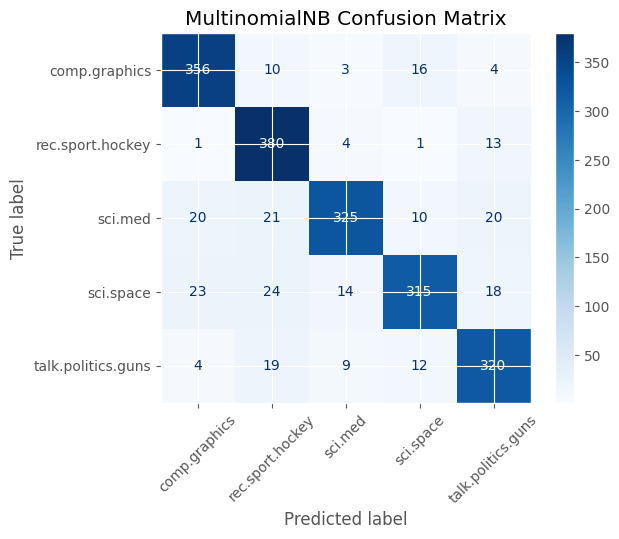

In [11]:
# YOUR CODE HERE
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english')),
    ('clf', MultinomialNB())
])
# Train model
nb_pipeline.fit(X_train_text, y_train)
# Predict
y_pred = nb_pipeline.predict(X_test_text)
# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=target_names))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('MultinomialNB Confusion Matrix')
plt.show()

---
## ✏️ Exercise 3: Compare All NB Variants
Train **MultinomialNB, BernoulliNB, ComplementNB** on TF-IDF and compare.

**Tasks:**
1. Train each variant
2. Record accuracy
3. Bar chart comparison
4. Discuss best variant

MultinomialNB Accuracy: 0.8733
BernoulliNB Accuracy: 0.7111
ComplementNB Accuracy: 0.8790


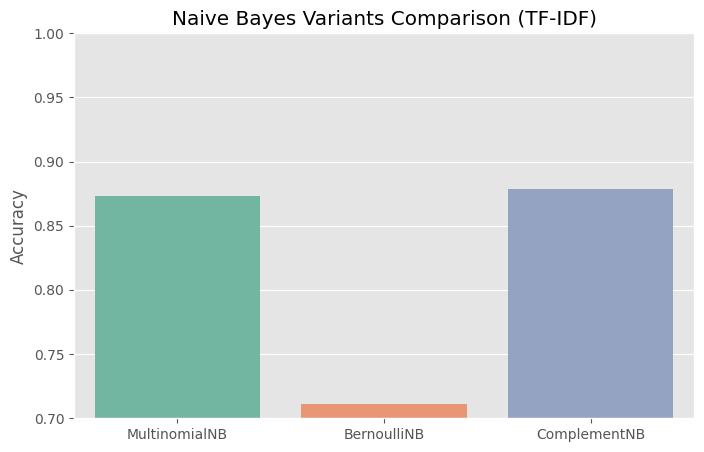

In [12]:
# YOUR CODE HERE
# Initialize models
models = {
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB(),
    'ComplementNB': ComplementNB()
}

accuracies = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english')),
        ('clf', model)
    ])
    pipeline.fit(X_train_text, y_train)
    y_pred = pipeline.predict(X_test_text)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Plot comparison
plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='Set2')
plt.title('Naive Bayes Variants Comparison (TF-IDF)')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.show()


---
## ✏️ Exercise 4: Alpha Smoothing Tuning
Test different `alpha` values: `[0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]`

**Tasks:**
1. 5-fold CV for each alpha
2. Plot alpha vs accuracy
3. Find optimal alpha

Alpha 0.001: CV Accuracy = 0.8975
Alpha 0.01: CV Accuracy = 0.8978
Alpha 0.1: CV Accuracy = 0.8996
Alpha 0.5: CV Accuracy = 0.8982
Alpha 1.0: CV Accuracy = 0.8975
Alpha 2.0: CV Accuracy = 0.8958
Alpha 5.0: CV Accuracy = 0.8831
Alpha 10.0: CV Accuracy = 0.8718


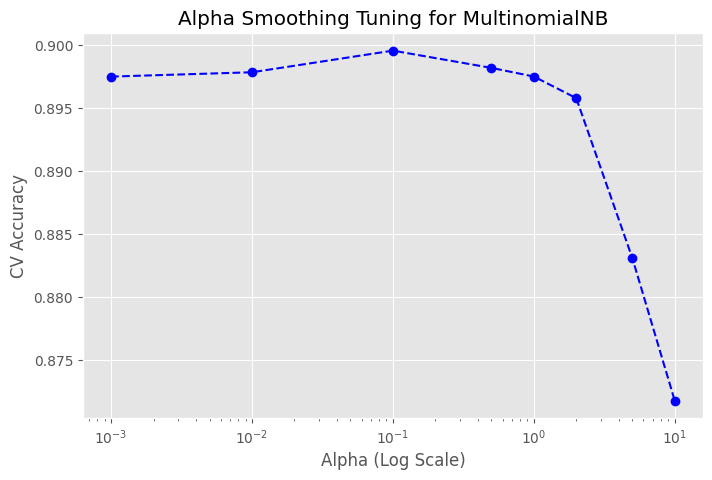


Optimal Alpha: 0.1


In [13]:
# YOUR CODE HERE
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
cv_scores = []

# Using TfidfVectorizer first so Cross Validation runs much faster
X_train_tfidf = TfidfVectorizer(max_features=10000, stop_words='english').fit_transform(X_train_text)

for alpha in alphas:
    clf = MultinomialNB(alpha=alpha)
    # 5-fold Cross Validation
    scores = cross_val_score(clf, X_train_tfidf, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"Alpha {alpha}: CV Accuracy = {scores.mean():.4f}")

# Plot alpha vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(alphas, cv_scores, marker='o', linestyle='dashed', color='b')
plt.xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('CV Accuracy')
plt.title('Alpha Smoothing Tuning for MultinomialNB')
plt.show()

# Find and print optimal alpha
optimal_alpha = alphas[np.argmax(cv_scores)]
print(f"\nOptimal Alpha: {optimal_alpha}")


---
## ✏️ Exercise 5: GaussianNB on Numerical Features
Engineer features from text: `word_count`, `char_count`, `avg_word_length`, etc.

**Tasks:**
1. Create numerical features from text
2. Train GaussianNB
3. Compare with MultinomialNB
4. Discuss differences

In [14]:
# YOUR CODE HERE
# Feature Engineering: Extract basic numerical features from text
def extract_features(texts):
    features = []
    for text in texts:
        words = text.split()
        word_count = len(words)
        char_count = len(text)
        avg_word_length = char_count / word_count if word_count > 0 else 0
        features.append([word_count, char_count, avg_word_length])
    return np.array(features)

X_train_num = extract_features(X_train_text)
X_test_num = extract_features(X_test_text)

# Train GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_num, y_train)
y_pred_gnb = gnb.predict(X_test_num)

print(f"GaussianNB Accuracy (Numerical Features): {accuracy_score(y_test, y_pred_gnb):.4f}")
print("\nConclusion: GaussianNB performs poorly here compared to Multinomial/ComplementNB because simple numeric features (like word length) aren't enough to distinguish between complex topics like Space, Medical, or Hockey.")


GaussianNB Accuracy (Numerical Features): 0.1993

Conclusion: GaussianNB performs poorly here compared to Multinomial/ComplementNB because simple numeric features (like word length) aren't enough to distinguish between complex topics like Space, Medical, or Hockey.


---
## 📝 Key Takeaways
1. Best NB variant for text: ...
2. Optimal alpha found: ...
3. GaussianNB vs MultinomialNB: ...
4. Speed comparison: ...